In [1]:
import os
import numpy as np
from scipy.signal import butter, filtfilt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

In [2]:
FS = 128
EPOCH_SEC = 8
BAND = (0.5, 45)

ROOT = "EEG_data"
HEALTHY_FOLDERS = ["Eyes_closed", "healthy_output"]
AD_FOLDER = "Eyes_closed"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CHANNELS = [
    "Fp1","Fp2","F3","F4","F7","F8","Fz",
    "C3","C4","Cz",
    "P3","P4","Pz",
    "T3","T4","T5","T6",
    "O1","O2"
]

In [3]:
def butter_bandpass(low, high, fs, order=6):
    nyq = 0.5 * fs
    return butter(order, [low/nyq, high/nyq], btype="band")

def bandpass_filter(eeg):
    b, a = butter_bandpass(*BAND, FS)
    eeg = filtfilt(b, a, eeg, axis=0)
    eeg = (eeg - np.mean(eeg, axis=0)) / (np.std(eeg, axis=0) + 1e-8)
    return eeg.astype(np.float32)

In [4]:
def epoch_signal(eeg):
    samples = FS * EPOCH_SEC
    epochs = []

    for i in range(0, eeg.shape[0], samples):
        ep = eeg[i:i+samples]
        if ep.shape[0] == samples:
            epochs.append(ep)

    return np.array(epochs)

In [5]:
def load_patient(folder):
    signals = []

    for ch in CHANNELS:
        path = os.path.join(folder, f"{ch}.txt")

        if not os.path.exists(path):
            return None

        signals.append(np.loadtxt(path))

    return np.stack(signals, axis=1)

In [6]:
def load_all():
    X, y = [], []

    healthy_base = os.path.join(ROOT, "Healthy")

    for folder in HEALTHY_FOLDERS:
        base = os.path.join(healthy_base, folder)

        if not os.path.exists(base):
            continue

        for patient in os.listdir(base):
            pdir = os.path.join(base, patient)

            eeg = load_patient(pdir)
            if eeg is None:
                continue

            eeg = bandpass_filter(eeg)
            epochs = epoch_signal(eeg)

            if len(epochs) > 0:
                X.append(epochs)
                y.append(0)

    ad_base = os.path.join(ROOT, "AD", AD_FOLDER)

    for patient in os.listdir(ad_base):
        pdir = os.path.join(ad_base, patient)

        eeg = load_patient(pdir)
        if eeg is None:
            continue

        eeg = bandpass_filter(eeg)
        epochs = epoch_signal(eeg)

        if len(epochs) > 0:
            X.append(epochs)
            y.append(1)

    print("Loaded", len(X), "subjects")
    return X, np.array(y)

In [7]:
def prepare_cldnn_data(Xp, yp, max_epochs_per_subject=50, max_healthy=300):
    healthy_X, ad_X = [], []

    for i in range(len(Xp)):
        epochs = Xp[i]

        if len(epochs) > max_epochs_per_subject:
            idx = np.random.choice(len(epochs), max_epochs_per_subject, replace=False)
            epochs = epochs[idx]

        for ep in epochs:
            if yp[i] == 0:
                healthy_X.append(ep.T)
            else:
                ad_X.append(ep.T)

    healthy_X = np.array(healthy_X)
    ad_X = np.array(ad_X)

    if len(healthy_X) > max_healthy:
        idx = np.random.choice(len(healthy_X), max_healthy, replace=False)
        healthy_X = healthy_X[idx]

    X = np.concatenate([healthy_X, ad_X])
    y = np.array([0]*len(healthy_X) + [1]*len(ad_X))

    idx = np.random.permutation(len(y))
    return X[idx], y[idx]

In [8]:
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [9]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        weights = torch.softmax(self.attn(x), dim=1)
        return torch.sum(weights * x, dim=1)

In [10]:
class CLDNN_Strong(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(len(CHANNELS), 64, 5, padding=2)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(64, 128, 3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(2)

        self.conv3 = nn.Conv1d(128, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.pool3 = nn.MaxPool1d(2)

        self.dropout = nn.Dropout(0.4)

        self.lstm = nn.LSTM(128, 64, batch_first=True, bidirectional=True)
        self.attention = Attention(128)

        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool3(torch.relu(self.bn3(self.conv3(x))))

        x = self.dropout(x)
        x = x.permute(0, 2, 1)

        x, _ = self.lstm(x)
        x = self.attention(x)

        x = torch.relu(self.fc1(x))
        return self.fc2(x)

In [11]:
def loso_split(Xp):
    for i in range(len(Xp)):
        train_idx = [j for j in range(len(Xp)) if j != i]
        test_idx = [i]
        yield train_idx, test_idx

In [12]:
def train_model(Xp, yp):
    print("===== FINAL STABLE LOSO =====")

    total_preds = []
    total_true = []

    for fold, (tr, te) in enumerate(loso_split(Xp), 1):
        print("\nFold", fold)

        Xtr, ytr = prepare_cldnn_data([Xp[i] for i in tr], yp[tr])
        print("Train distribution:", np.bincount(ytr))

        dataset = EEGDataset(Xtr, ytr)
        loader = DataLoader(dataset, batch_size=64, shuffle=True)

        model = CLDNN_Strong().to(device)

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=1e-3)

        for epoch in range(8):
            model.train()
            losses = []

            for data, target in loader:
                data = data.to(device)
                target = target.to(device)

                optimizer.zero_grad()
                output = model(data)
                loss = criterion(output, target)

                loss.backward()
                optimizer.step()

                losses.append(loss.item())

            print("Epoch", epoch, "Loss:", np.mean(losses))

        model.eval()

        for i in te:
            data_np = np.array([ep.T for ep in Xp[i]])
            data = torch.tensor(data_np, dtype=torch.float32).to(device)

            with torch.no_grad():
                probs = torch.softmax(model(data), dim=1).cpu().numpy()

            mean_probs = np.mean(probs, axis=0)

            pred = 1 if mean_probs[1] > 0.6 else 0

            print("Actual:", yp[i], "Predicted:", pred)

            total_preds.append(pred)
            total_true.append(yp[i])

    return total_preds, total_true

In [13]:
Xp, yp = load_all()

if len(Xp) == 0:
    print("No data found")
else:
    total_preds, total_true = train_model(Xp, yp)

Loaded 121 subjects
===== FINAL STABLE LOSO =====

Fold 1
Train distribution: [300  80]
Epoch 0 Loss: 0.5198457688093185
Epoch 1 Loss: 0.2605073278148969
Epoch 2 Loss: 0.09831810804704826
Epoch 3 Loss: 0.04778682099034389
Epoch 4 Loss: 0.03149978226671616
Epoch 5 Loss: 0.013053280922273794
Epoch 6 Loss: 0.01606912027151945
Epoch 7 Loss: 0.014367170699794466
Actual: 0 Predicted: 0

Fold 2
Train distribution: [300  80]
Epoch 0 Loss: 0.5329705129067103
Epoch 1 Loss: 0.22881470372279486
Epoch 2 Loss: 0.06549137582381566
Epoch 3 Loss: 0.018174644093960524
Epoch 4 Loss: 0.006297460737793396
Epoch 5 Loss: 0.026737971260445192
Epoch 6 Loss: 0.02458180125298289
Epoch 7 Loss: 0.003055963209286953
Actual: 0 Predicted: 1

Fold 3
Train distribution: [300  80]
Epoch 0 Loss: 0.581918478012085
Epoch 1 Loss: 0.2606108834346135
Epoch 2 Loss: 0.07493097459276517
Epoch 3 Loss: 0.03409439465031028
Epoch 4 Loss: 0.022609212901443243
Epoch 5 Loss: 0.003787650765540699
Epoch 6 Loss: 0.0027227779016053924
Epoc

===== FINAL EVALUATION (CLDNN) =====
Total Subjects: 121

Confusion Matrix (Values):
[[34  7]
 [ 1 79]]

Detailed:
TN (Healthy → Healthy): 34
FP (Healthy → AD): 7
FN (AD → Healthy): 1
TP (AD → AD): 79

Metrics:
Accuracy: 93.39 %
Precision: 0.9186
Recall: 0.9875
F1 Score: 0.9518


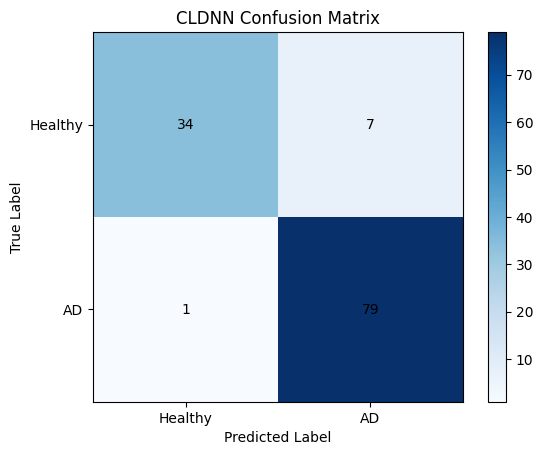

In [14]:
# ===== CELL 14: CLDNN FINAL EVALUATION =====

import numpy as np
import matplotlib.pyplot as plt

# Convert to numpy
total_preds = np.array(total_preds)
total_true = np.array(total_true)

print("===== FINAL EVALUATION (CLDNN) =====")
print("Total Subjects:", len(total_preds))

# ===== CONFUSION MATRIX VALUES =====
tp = np.sum((total_preds == 1) & (total_true == 1))  # AD → AD
tn = np.sum((total_preds == 0) & (total_true == 0))  # Healthy → Healthy
fp = np.sum((total_preds == 1) & (total_true == 0))  # Healthy → AD
fn = np.sum((total_preds == 0) & (total_true == 1))  # AD → Healthy

# Matrix format
cm = np.array([[tn, fp],
               [fn, tp]])

print("\nConfusion Matrix (Values):")
print(cm)

print("\nDetailed:")
print("TN (Healthy → Healthy):", tn)
print("FP (Healthy → AD):", fp)
print("FN (AD → Healthy):", fn)
print("TP (AD → AD):", tp)

# ===== METRICS =====
accuracy = (tp + tn) / len(total_preds)
precision = tp / (tp + fp + 1e-8)
recall = tp / (tp + fn + 1e-8)
f1 = 2 * precision * recall / (precision + recall + 1e-8)

print("\nMetrics:")
print("Accuracy:", round(accuracy * 100, 2), "%")
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

# ===== PLOT CONFUSION MATRIX (UPDATED COLOR) =====
plt.figure()
plt.imshow(cm, cmap='Blues')  # ✅ Changed to blue-white

plt.title("CLDNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Healthy", "AD"])
plt.yticks([0, 1], ["Healthy", "AD"])

# Annotate values
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()